# Deep Learning com Keras — Aula Completa e Conceitual

Notebook completo com teoria e prática.

## O que é Deep Learning?

Deep Learning é uma subárea de Machine Learning baseada em redes neurais profundas.

Características:
- múltiplas camadas;
- aprendizado automático de representações;
- muito usado em imagens, áudio e texto.

## O que é um neurônio artificial?

Cada neurônio:
- recebe entradas;
- aplica pesos;
- soma resultados;
- aplica função de ativação.

Formula:

$$y=f(wx+b)$$

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

## Dataset MNIST

MNIST contém imagens 28x28 de dígitos escritos à mão.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(60000,)


## Visualização

Cada imagem possui 784 pixels.

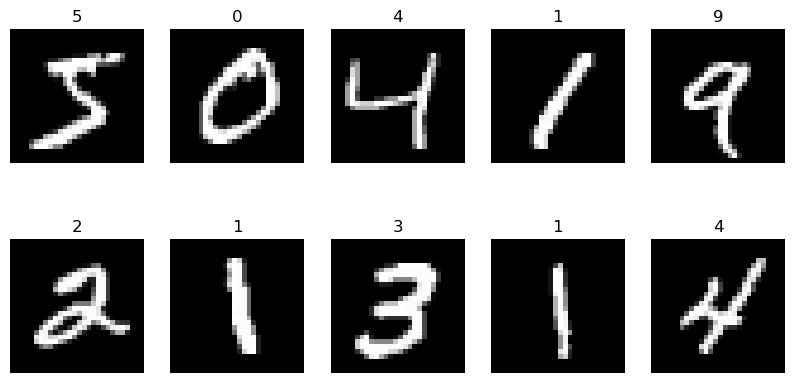

In [3]:
fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(y_train[i])
    ax.axis('off')

plt.show()

## Normalização

Transforma pixels de 0-255 para 0-1.

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## One-Hot Encoding

Converte classes em vetores categóricos.

In [5]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

## Funções de ativação

### ReLU

$$f(x)=max(0,x)$$

Muito usada em camadas ocultas.

### Softmax

Transforma saída em probabilidades.

## MLP — Multilayer Perceptron

Rede totalmente conectada.

Limitação:
- perde estrutura espacial da imagem.

In [6]:
mlp_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

mlp_model.summary()

c:\Users\hjmou\miniconda3\envs\aula\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Optimizer

Optimizer controla atualização dos pesos.

### Adam

Muito usado porque:
- converge rápido;
- estável;
- funciona bem em muitos cenários.

In [7]:
mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Epoch e Batch Size

### Epoch
Uma passagem completa pelos dados.

### Batch Size
Quantidade processada por vez.

In [8]:
history = mlp_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9226 - loss: 0.2662 - val_accuracy: 0.9596 - val_loss: 0.1397
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9667 - loss: 0.1104 - val_accuracy: 0.9676 - val_loss: 0.1077
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9752 - loss: 0.0784 - val_accuracy: 0.9743 - val_loss: 0.0917
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9821 - loss: 0.0574 - val_accuracy: 0.9744 - val_loss: 0.0884
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9856 - loss: 0.0446 - val_accuracy: 0.9708 - val_loss: 0.1104
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9887 - loss: 0.0355 - val_accuracy: 0.9730 - val_loss: 0.1057
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9903 - loss: 0.0300 - val_accuracy: 0.9759 - val_loss: 0.0975
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9915 - loss: 0.0262 - 

## Histórico de treinamento

### Accuracy
Percentual de acertos.

### Loss
Erro do modelo.

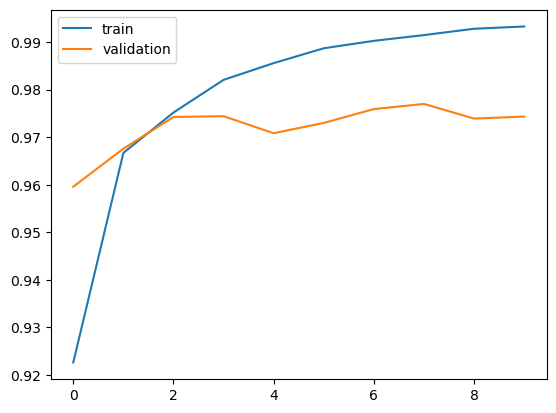

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','validation'])
plt.show()

## Overfitting

Ocorre quando o modelo memoriza treino.

Sinais:
- treino melhora;
- validação piora.

## Dropout

Desliga neurônios aleatoriamente.

Objetivo:
- reduzir overfitting.

In [10]:
drop_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

## EarlyStopping

Interrompe treino automaticamente quando validação para de melhorar.

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## CNN — Convolutional Neural Networks

Especializadas em imagens.

Vantagens:
- preservam estrutura espacial;
- aprendem padrões locais.

## Convolução

Filtros percorrem imagem procurando padrões.

Exemplos:
- bordas;
- curvas;
- texturas.

## Pooling

Reduz dimensionalidade.

### MaxPooling
Mantém valores mais importantes.

In [12]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [13]:
cnn_model = Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

cnn_model.summary()

c:\Users\hjmou\miniconda3\envs\aula\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9446 - loss: 0.1802 - val_accuracy: 0.9844 - val_loss: 0.0530
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9821 - loss: 0.0592 - val_accuracy: 0.9878 - val_loss: 0.0422
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9865 - loss: 0.0436 - val_accuracy: 0.9892 - val_loss: 0.0372
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9899 - loss: 0.0328 - val_accuracy: 0.9897 - val_loss: 0.0386
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9910 - loss: 0.0271 - val_accuracy: 0.9904 - val_loss: 0.0335
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9933 - loss: 0.0214 - val_accuracy: 0.9886 - val_loss: 0.0414
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9937 - loss: 0.0196 - val_accuracy: 0.9898 - val_loss: 0.0367
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9948 - loss:

## Comparação MLP vs CNN

| MLP | CNN |
|---|---|
| trata imagem como vetor | preserva estrutura espacial |
| simples | poderosa |
| pior para imagens | excelente para imagens |

## GPU vs CPU

Deep Learning se beneficia muito de GPU porque:
- há muitas multiplicações matriciais;
- processamento paralelo.

## Salvando modelos

In [16]:
cnn_model.save('cnn_mnist.keras')

## Carregando modelos

In [17]:
loaded_model = load_model('cnn_mnist.keras')

## Exercícios

1. Alterar neurônios.
2. Alterar dropout.
3. Trocar optimizer.
4. Adicionar mais camadas convolucionais.
5. Comparar MLP vs CNN.